# 1. Dependencias

In [ ]:
# Instalación de dependencias necesarias para el proyecto

pip install catboost scikit-learn pandas numpy pyarrow matplotlib seaborn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.8 MB/s eta 0:00:37
   ---------------------------------------- 1.0/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.8/101.7 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 2.4/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 3.4/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 3.9/101.7 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 4.7/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 5.5/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 6.3/101.7 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 7.6/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.4/101.7 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 9.4/101.7 MB 3.8 MB/s eta 0

In [ ]:

# Importación de dependencias necesarias para el proyecto

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_pinball_loss


# 2. Configuración del experimento

In [ ]:

# Cofiguración del experimento

@dataclass(frozen=True)
class ConfiguracionExperimento:
    """Configuración general del pipeline de demanda."""

    fecha_inicio: str = "2024-01-01"
    fecha_fin: str = "2024-03-31"

    lags: tuple[int, ...] = (1, 2, 3, 4)
    ventanas: tuple[int, ...] = (2, 4)
    cuantiles: tuple[float, ...] = (0.10, 0.50, 0.90)

    semanas_backtesting: int = 4

    iterations: int = 400
    depth: int = 6
    learning_rate: float = 0.05

    random_state: int = 42


CONFIG = ConfiguracionExperimento()


# 3. Lectura y validación de archivos

In [ ]:
# Lectura y validación de archivos

COLUMNAS_VENTAS = {
    "fecha",
    "id_tienda",
    "id_producto",
    "unidades_vendidas",
}

COLUMNAS_INVENTARIO = {
    "id_tienda",
    "id_producto",
    "stock_actual",
}

COLUMNAS_PRODUCTOS = {
    "id_producto",
    "nombre",
    "costo_unitario",
    "precio_venta",
    "costo_almacenamiento_semanal",
}

COLUMNAS_TIENDAS = {
    "id_tienda",
    "ciudad",
    "tamaño_m2",
}


def validar_columnas(
    df: pd.DataFrame,
    columnas_requeridas: set[str],
    nombre_df: str,
) -> None:
    """Valida que un DataFrame contenga las columnas requeridas."""

    faltantes = columnas_requeridas.difference(df.columns)

    if faltantes:
        raise ValueError(
            f"{nombre_df} no contiene las columnas: "
            f"{sorted(faltantes)}"
        )


def cargar_datos(
    ruta_datos: str | Path = "data/01_supply_optimization",   #--> Ajustar ruta conforme a la estructura de carpetas del proyecto
) -> dict[str, pd.DataFrame]:
    """Carga y valida las cuatro fuentes del ejercicio."""

    ruta_datos = Path(ruta_datos)

    ventas = pd.read_csv(
        ruta_datos / "ventas_historicas.csv",
        parse_dates=["fecha"],
    )

    inventario = pd.read_csv(
        ruta_datos / "inventario_actual.csv"
    )

    productos = pd.read_csv(
        ruta_datos / "catalogo_productos.csv"
    )

    tiendas = pd.read_csv(
        ruta_datos / "maestro_tiendas.csv"
    )

    validar_columnas(
        ventas,
        COLUMNAS_VENTAS,
        "ventas_historicas",
    )

    validar_columnas(
        inventario,
        COLUMNAS_INVENTARIO,
        "inventario_actual",
    )

    validar_columnas(
        productos,
        COLUMNAS_PRODUCTOS,
        "catalogo_productos",
    )

    validar_columnas(
        tiendas,
        COLUMNAS_TIENDAS,
        "maestro_tiendas",
    )

    return {
        "ventas": ventas,
        "inventario": inventario,
        "productos": productos,
        "tiendas": tiendas,
    }


# 4. Validaciones de calidad

In [5]:
# Validación de la calidad de los datos

def validar_calidad_datos(
    ventas: pd.DataFrame,
    inventario: pd.DataFrame,
    productos: pd.DataFrame,
    tiendas: pd.DataFrame,
) -> dict[str, int]:
    """Ejecuta validaciones básicas de calidad."""

    resultados = {
        "ventas_fecha_nula": int(
            ventas["fecha"].isna().sum()
        ),
        "ventas_negativas": int(
            (ventas["unidades_vendidas"] < 0).sum()
        ),
        "inventario_negativo": int(
            (inventario["stock_actual"] < 0).sum()
        ),
        "costos_unitarios_negativos": int(
            (productos["costo_unitario"] < 0).sum()
        ),
        "precios_negativos": int(
            (productos["precio_venta"] < 0).sum()
        ),
        "almacenamiento_negativo": int(
            (
                productos["costo_almacenamiento_semanal"]
                < 0
            ).sum()
        ),
        "productos_duplicados": int(
            productos.duplicated(
                subset=["id_producto"]
            ).sum()
        ),
        "tiendas_duplicadas": int(
            tiendas.duplicated(
                subset=["id_tienda"]
            ).sum()
        ),
        "inventario_duplicado": int(
            inventario.duplicated(
                subset=["id_tienda", "id_producto"]
            ).sum()
        ),
    }

    return resultados


In [7]:

fuentes = cargar_datos("data/01_supply_optimization")

resultados_calidad = validar_calidad_datos(
    ventas=fuentes["ventas"],
    inventario=fuentes["inventario"],
    productos=fuentes["productos"],
    tiendas=fuentes["tiendas"],
)

pd.Series(resultados_calidad).sort_values(
    ascending=False
)


ventas_fecha_nula             0
ventas_negativas              0
inventario_negativo           0
costos_unitarios_negativos    0
precios_negativos             0
almacenamiento_negativo       0
productos_duplicados          0
tiendas_duplicadas            0
inventario_duplicado          0
dtype: int64

# 5. Construcción de la base semanal

In [9]:
# Construcción Base Semanal (Datos para entrenarmiento y evaluación del modelo)


def obtener_inicio_semana(
    fechas: pd.Series,
) -> pd.Series:
    """Convierte una fecha en el lunes de su semana."""

    return (
        fechas
        - pd.to_timedelta(fechas.dt.weekday, unit="D")
    ).dt.normalize()


def construir_ventas_semanales(
    ventas: pd.DataFrame,
    productos: pd.DataFrame,
    tiendas: pd.DataFrame,
    config: ConfiguracionExperimento,
) -> pd.DataFrame:
    """Construye la demanda semanal por tienda y producto."""

    ventas = ventas.copy()
    productos = productos.copy()
    tiendas = tiendas.copy()

    ventas["fecha"] = pd.to_datetime(
        ventas["fecha"],
        errors="coerce",
    )

    fecha_inicio = pd.Timestamp(config.fecha_inicio)
    fecha_fin = pd.Timestamp(config.fecha_fin)

    ventas = ventas[
        ventas["fecha"].between(
            fecha_inicio,
            fecha_fin,
            inclusive="both",
        )
    ].copy()

    ventas["semana"] = obtener_inicio_semana(
        ventas["fecha"]
    )

    ventas_semanales = (
        ventas
        .groupby(
            ["semana", "id_tienda", "id_producto"],
            as_index=False,
            observed=True,
        )
        .agg(
            ventas_semanales=(
                "unidades_vendidas",
                "sum",
            )
        )
    )

    ventas_semanales = ventas_semanales.merge(
        productos,
        on="id_producto",
        how="left",
        validate="many_to_one",
    )

    ventas_semanales = ventas_semanales.merge(
        tiendas,
        on="id_tienda",
        how="left",
        validate="many_to_one",
    )

    ventas_semanales = ventas_semanales.rename(
        columns={
            "costo_almacenamiento_semanal":
                "costo_almacenamiento",
            "tamaño_m2":
                "tamano_tienda",
        }
    )

    ventas_semanales["margen_unitario"] = (
        ventas_semanales["precio_venta"]
        - ventas_semanales["costo_unitario"]
    )

    ventas_semanales["margen_porcentual"] = np.where(
        ventas_semanales["precio_venta"] > 0,
        (
            ventas_semanales["margen_unitario"]
            / ventas_semanales["precio_venta"]
        ),
        np.nan,
    )

    return (
        ventas_semanales
        .sort_values(
            ["id_tienda", "id_producto", "semana"]
        )
        .reset_index(drop=True)
    )


In [10]:
# Completar el panel SKU-Tienda-Semana: Si alguna semana no cotienen ventas para la combinación SKU-Tienda-Semana, se debe completar para que los resagos sean consistentes

def completar_panel_semanal(
    df: pd.DataFrame,
    fecha_inicio: str,
    fecha_fin: str,
) -> pd.DataFrame:
    """Construye un panel semanal continuo por SKU-Tienda.

    Las semanas sin registros se completan inicialmente con cero
    ventas. Esta imputación supone que la combinación estaba activa
    y disponible, lo cual debe documentarse como limitación.
    """

    df = df.copy()
    df["semana"] = pd.to_datetime(df["semana"])

    inicio = obtener_inicio_semana(
        pd.Series([pd.Timestamp(fecha_inicio)])
    ).iloc[0]

    fin = obtener_inicio_semana(
        pd.Series([pd.Timestamp(fecha_fin)])
    ).iloc[0]

    semanas = pd.date_range(
        start=inicio,
        end=fin,
        freq="7D",
    )

    combinaciones = (
        df[["id_tienda", "id_producto"]]
        .drop_duplicates()
        .assign(clave=1)
    )

    calendario = pd.DataFrame({
        "semana": semanas,
        "clave": 1,
    })

    panel = (
        combinaciones
        .merge(calendario, on="clave", how="inner")
        .drop(columns="clave")
    )

    panel = panel.merge(
        df,
        on=["semana", "id_tienda", "id_producto"],
        how="left",
        validate="one_to_one",
    )

    panel["ventas_semanales"] = (
        panel["ventas_semanales"]
        .fillna(0.0)
        .astype(float)
    )

    columnas_producto = [
        "nombre",
        "costo_unitario",
        "precio_venta",
        "costo_almacenamiento",
        "margen_unitario",
        "margen_porcentual",
    ]

    columnas_tienda = [
        "ciudad",
        "tamano_tienda",
    ]

    panel = panel.sort_values(
        ["id_tienda", "id_producto", "semana"]
    )

    panel[columnas_producto] = (
        panel
        .groupby(
            "id_producto",
            observed=True,
        )[columnas_producto]
        .transform(lambda x: x.ffill().bfill())
    )

    panel[columnas_tienda] = (
        panel
        .groupby(
            "id_tienda",
            observed=True,
        )[columnas_tienda]
        .transform(lambda x: x.ffill().bfill())
    )

    panel["registro_original"] = (
        panel["nombre"].notna()
    )

    return panel.reset_index(drop=True)


In [ ]:

# Función para generar el panel de los datos para el modelo
def generar_panel_modelo(
    ventas: pd.DataFrame,
    productos: pd.DataFrame,
    tiendas: pd.DataFrame,
    config: ConfiguracionExperimento,
) -> pd.DataFrame:
    """Ejecuta el pipeline de preparación de la base semanal."""

    ventas = ventas.copy()

    ventas["fecha"] = pd.to_datetime(
        ventas["fecha"],
        errors="coerce",
    )

    ventas = ventas[
        ventas["fecha"].between(
            pd.Timestamp(config.fecha_inicio),
            pd.Timestamp(config.fecha_fin),
            inclusive="both",
        )
    ].copy()

    ventas["semana"] = obtener_inicio_semana(
        ventas["fecha"]
    )

    agregada = (
        ventas
        .groupby(
            ["semana", "id_tienda", "id_producto"],
            as_index=False,
            observed=True,
        )
        .agg(
            ventas_semanales=(
                "unidades_vendidas",
                "sum",
            )
        )
    )

    combinaciones = (
        agregada[["id_tienda", "id_producto"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    semana_inicio = obtener_inicio_semana(
        pd.Series([pd.Timestamp(config.fecha_inicio)])
    ).iloc[0]

    semana_fin = obtener_inicio_semana(
        pd.Series([pd.Timestamp(config.fecha_fin)])
    ).iloc[0]

    semanas = pd.DataFrame({
        "semana": pd.date_range(
            semana_inicio,
            semana_fin,
            freq="7D",
        )
    })

    panel = (
        combinaciones
        .assign(clave=1)
        .merge(
            semanas.assign(clave=1),
            on="clave",
            how="inner",
        )
        .drop(columns="clave")
    )

    panel = panel.merge(
        agregada,
        on=["semana", "id_tienda", "id_producto"],
        how="left",
        validate="one_to_one",
        indicator="estado_registro",
    )

    panel["semana_sin_registro"] = (
        panel["estado_registro"] == "left_only"
    ).astype(int)

    panel = panel.drop(columns="estado_registro")

    panel["ventas_semanales"] = (
        panel["ventas_semanales"]
        .fillna(0.0)
        .clip(lower=0)
        .astype(float)
    )

    panel = panel.merge(
        productos,
        on="id_producto",
        how="left",
        validate="many_to_one",
    )

    panel = panel.merge(
        tiendas,
        on="id_tienda",
        how="left",
        validate="many_to_one",
    )

    panel = panel.rename(
        columns={
            "costo_almacenamiento_semanal":
                "costo_almacenamiento",
            "tamaño_m2":
                "tamano_tienda",
        }
    )

    panel["margen_unitario"] = (
        panel["precio_venta"]
        - panel["costo_unitario"]
    )

    panel["margen_porcentual"] = np.where(
        panel["precio_venta"] > 0,
        (
            panel["margen_unitario"]
            / panel["precio_venta"]
        ),
        np.nan,
    )

    return (
        panel
        .sort_values(
            ["id_tienda", "id_producto", "semana"]
        )
        .reset_index(drop=True)
    )



In [ ]:

# Se ejecuta el pipeline de preparación de la base semanal para el modelo
data_modelo = generar_panel_modelo(
    ventas=fuentes["ventas"],
    productos=fuentes["productos"],
    tiendas=fuentes["tiendas"],
    config=CONFIG,
)

print(data_modelo.shape)
data_modelo.head()


(2080, 14)


,id_tienda,id_producto,semana,ventas_semanales,semana_sin_registro,nombre,categoria,costo_unitario,precio_venta,costo_almacenamiento,ciudad,tamano_tienda,margen_unitario,margen_porcentual
0,STORE_01,PROD_001,2024-01-01,42.0,0,Tinto,Bebidas,800,2500,10,Bogotá,28,1700,0.68
1,STORE_01,PROD_001,2024-01-08,45.0,0,Tinto,Bebidas,800,2500,10,Bogotá,28,1700,0.68
2,STORE_01,PROD_001,2024-01-15,47.0,0,Tinto,Bebidas,800,2500,10,Bogotá,28,1700,0.68
3,STORE_01,PROD_001,2024-01-22,57.0,0,Tinto,Bebidas,800,2500,10,Bogotá,28,1700,0.68
4,STORE_01,PROD_001,2024-01-29,54.0,0,Tinto,Bebidas,800,2500,10,Bogotá,28,1700,0.68


In [ ]:

# Se valida el número de semanas
semanas_disponibles = (
    data_modelo["semana"]
    .drop_duplicates()
    .sort_values()
)

print(f"Número de semanas: {len(semanas_disponibles)}")
print(semanas_disponibles.tolist())


Número de semanas: 13
[Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-08 00:00:00'), Timestamp('2024-01-15 00:00:00'), Timestamp('2024-01-22 00:00:00'), Timestamp('2024-01-29 00:00:00'), Timestamp('2024-02-05 00:00:00'), Timestamp('2024-02-12 00:00:00'), Timestamp('2024-02-19 00:00:00'), Timestamp('2024-02-26 00:00:00'), Timestamp('2024-03-04 00:00:00'), Timestamp('2024-03-11 00:00:00'), Timestamp('2024-03-18 00:00:00'), Timestamp('2024-03-25 00:00:00')]


# 6. Feature Engineering

In [16]:

# Función para crear variables temporales sin utilizar información futura
def crear_variables_modelo(
    df: pd.DataFrame,
    lags: tuple[int, ...],
    ventanas: tuple[int, ...],
) -> pd.DataFrame:
    """Crea variables temporales sin utilizar información futura."""

    resultado = (
        df
        .copy()
        .sort_values(
            ["id_tienda", "id_producto", "semana"]
        )
        .reset_index(drop=True)
    )

    columnas_grupo = [
        "id_tienda",
        "id_producto",
    ]

    grupo = resultado.groupby(
        columnas_grupo,
        observed=True,
    )["ventas_semanales"]

    for lag in lags:
        resultado[f"ventas_lag_{lag}"] = (
            grupo.shift(lag)
        )

    for ventana in ventanas:
        resultado[f"ventas_media_{ventana}"] = (
            grupo.transform(
                lambda serie: (
                    serie
                    .shift(1)
                    .rolling(
                        window=ventana,
                        min_periods=1,
                    )
                    .mean()
                )
            )
        )

        resultado[f"ventas_std_{ventana}"] = (
            grupo.transform(
                lambda serie: (
                    serie
                    .shift(1)
                    .rolling(
                        window=ventana,
                        min_periods=2,
                    )
                    .std()
                )
            )
        )

        resultado[f"ventas_min_{ventana}"] = (
            grupo.transform(
                lambda serie: (
                    serie
                    .shift(1)
                    .rolling(
                        window=ventana,
                        min_periods=1,
                    )
                    .min()
                )
            )
        )

        resultado[f"ventas_max_{ventana}"] = (
            grupo.transform(
                lambda serie: (
                    serie
                    .shift(1)
                    .rolling(
                        window=ventana,
                        min_periods=1,
                    )
                    .max()
                )
            )
        )

        resultado[f"proporcion_ceros_{ventana}"] = (
            grupo.transform(
                lambda serie: (
                    serie
                    .shift(1)
                    .eq(0)
                    .rolling(
                        window=ventana,
                        min_periods=1,
                    )
                    .mean()
                )
            )
        )

    resultado["tendencia_1_4"] = (
        resultado.get("ventas_media_2", np.nan)
        - resultado.get("ventas_media_4", np.nan)
    )

    resultado["semana_anio"] = (
        resultado["semana"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

   
    resultado["indice_semana"] = (
        resultado["semana"]
        .rank(method="dense")
        .astype(int)
    )

    resultado["ventas_promedio_producto"] = (
        resultado
        .groupby(
            ["semana", "id_producto"],
            observed=True,
        )["ventas_semanales"]
        .transform("mean")
    )

    resultado["ventas_promedio_tienda"] = (
        resultado
        .groupby(
            ["semana", "id_tienda"],
            observed=True,
        )["ventas_semanales"]
        .transform("mean")
    )

    # Las variables agregadas anteriores contienen ventas de la
    # semana objetivo. Deben rezagarse antes de usarlas.
    resultado["producto_media_semana_anterior"] = (
        resultado
        .groupby(
            "id_producto",
            observed=True,
        )["ventas_promedio_producto"]
        .shift(1)
    )

    resultado["tienda_media_semana_anterior"] = (
        resultado
        .groupby(
            "id_tienda",
            observed=True,
        )["ventas_promedio_tienda"]
        .shift(1)
    )

    resultado = resultado.drop(
        columns=[
            "ventas_promedio_producto",
            "ventas_promedio_tienda",
        ]
    )

    return resultado


In [ ]:

# Se ejecuta la función
data_features = crear_variables_modelo(
    df=data_modelo,
    lags=CONFIG.lags,
    ventanas=CONFIG.ventanas,
)

data_features.head()


,id_tienda,id_producto,semana,ventas_semanales,semana_sin_registro,nombre,categoria,costo_unitario,precio_venta,costo_almacenamiento,...,ventas_media_4,ventas_std_4,ventas_min_4,ventas_max_4,proporcion_ceros_4,tendencia_1_4,semana_anio,indice_semana,producto_media_semana_anterior,tienda_media_semana_anterior
0,STORE_01,PROD_001,2024-01-01,42.0,0,Tinto,Bebidas,800,2500,10,...,NaN,NaN,NaN,NaN,0.0,NaN,1,1,NaN,NaN
1,STORE_01,PROD_001,2024-01-08,45.0,0,Tinto,Bebidas,800,2500,10,...,42.000000,NaN,42.0,42.0,0.0,0.000000,2,2,54.1,75.375
2,STORE_01,PROD_001,2024-01-15,47.0,0,Tinto,Bebidas,800,2500,10,...,43.500000,2.121320,42.0,45.0,0.0,0.000000,3,3,56.3,72.375
3,STORE_01,PROD_001,2024-01-22,57.0,0,Tinto,Bebidas,800,2500,10,...,44.666667,2.516611,42.0,47.0,0.0,1.333333,4,4,60.4,64.500
4,STORE_01,PROD_001,2024-01-29,54.0,0,Tinto,Bebidas,800,2500,10,...,47.750000,6.500000,42.0,57.0,0.0,4.250000,5,5,56.5,70.125


# 7. Validaciones para prevenir fuga de información

In [19]:

def validar_features(
    df: pd.DataFrame,
    lags: tuple[int, ...],
) -> None:
    """Valida consistencia básica de las variables temporales."""

    claves = ["semana", "id_tienda", "id_producto"]

    duplicados = df.duplicated(
        subset=claves
    ).sum()

    if duplicados > 0:
        raise ValueError(
            f"Se encontraron {duplicados} claves duplicadas."
        )

    for lag in lags:
        columna = f"ventas_lag_{lag}"

        if columna not in df.columns:
            raise ValueError(
                f"No se generó la variable {columna}."
            )

    if "ventas_lag_1" in df.columns:
        lag_esperado = (
            df
            .groupby(
                ["id_tienda", "id_producto"],
                observed=True,
            )["ventas_semanales"]
            .shift(1)
        )

        consistente = (
            df["ventas_lag_1"].fillna(-999999)
            == lag_esperado.fillna(-999999)
        ).all()

        if not consistente:
            raise ValueError(
                "ventas_lag_1 no coincide con la semana anterior."
            )


validar_features(
    data_features,
    CONFIG.lags,
)


# 8. Variables del modelo

In [20]:
# Se definen las variables que se van a utilizar en el modelo

def obtener_columnas_modelo(
    lags: tuple[int, ...],
    ventanas: tuple[int, ...],
) -> tuple[list[str], list[str]]:
    """Devuelve variables numéricas y categóricas."""

    numericas = [
        "precio_venta",
        "costo_unitario",
        "costo_almacenamiento",
        "margen_unitario",
        "margen_porcentual",
        "tamano_tienda",
        "semana_anio",
        "indice_semana",
        "producto_media_semana_anterior",
        "tienda_media_semana_anterior",
    ]

    numericas += [
        f"ventas_lag_{lag}"
        for lag in lags
    ]

    for ventana in ventanas:
        numericas.extend([
            f"ventas_media_{ventana}",
            f"ventas_std_{ventana}",
            f"ventas_min_{ventana}",
            f"ventas_max_{ventana}",
            f"proporcion_ceros_{ventana}",
        ])

    if 2 in ventanas and 4 in ventanas:
        numericas.append("tendencia_1_4")

    categoricas = [
        "id_tienda",
        "id_producto",
        "ciudad",
    ]

    return numericas, categoricas


In [ ]:

# Función que asegura que las variables numéricas y categóricas tengan el formato adecuado
def preparar_matriz_modelo(
    df: pd.DataFrame,
    columnas_numericas: list[str],
    columnas_categoricas: list[str],
) -> pd.DataFrame:
    """Prepara tipos y faltantes para CatBoost."""

    X = df[
        columnas_numericas + columnas_categoricas
    ].copy()

    for columna in columnas_numericas:
        X[columna] = pd.to_numeric(
            X[columna],
            errors="coerce",
        )

        X[columna] = X[columna].replace(
            [np.inf, -np.inf],
            np.nan,
        )

    for columna in columnas_categoricas:
        X[columna] = (
            X[columna]
            .fillna("DESCONOCIDO")
            .astype(str)
        )

    return X


# 9. Métricas

In [22]:

def calcular_wape(
    y_real: np.ndarray | pd.Series,
    y_predicho: np.ndarray | pd.Series,
) -> float:
    """Calcula Weighted Absolute Percentage Error."""

    y_real = np.asarray(y_real, dtype=float)
    y_predicho = np.asarray(y_predicho, dtype=float)

    denominador = np.abs(y_real).sum()

    if denominador == 0:
        return np.nan

    return float(
        np.abs(y_real - y_predicho).sum()
        / denominador
    )


def calcular_bias(
    y_real: np.ndarray | pd.Series,
    y_predicho: np.ndarray | pd.Series,
) -> float:
    """Calcula el sesgo normalizado del pronóstico."""

    y_real = np.asarray(y_real, dtype=float)
    y_predicho = np.asarray(y_predicho, dtype=float)

    denominador = np.abs(y_real).sum()

    if denominador == 0:
        return np.nan

    return float(
        (y_predicho - y_real).sum()
        / denominador
    )


def calcular_metricas(
    y_real: pd.Series,
    y_predicho: np.ndarray,
    modelo: str,
    semana: pd.Timestamp,
    cuantil: float = 0.50,
) -> dict[str, Any]:
    """Calcula métricas de una predicción."""

    y_predicho = np.clip(
        np.asarray(y_predicho, dtype=float),
        a_min=0,
        a_max=None,
    )

    return {
        "modelo": modelo,
        "semana_validacion": semana,
        "cuantil": cuantil,
        "mae": mean_absolute_error(
            y_real,
            y_predicho,
        ),
        "wape": calcular_wape(
            y_real,
            y_predicho,
        ),
        "bias": calcular_bias(
            y_real,
            y_predicho,
        ),
        "pinball_loss": mean_pinball_loss(
            y_real,
            y_predicho,
            alpha=cuantil,
        ),
        "cobertura": float(
            (np.asarray(y_real) <= y_predicho).mean()
        ),
        "ventas_reales": float(y_real.sum()),
        "ventas_predichas": float(y_predicho.sum()),
        "n_observaciones": len(y_real),
    }


# 10. Backtesting de baselines

In [23]:

def backtesting_baselines(
    df: pd.DataFrame,
    semanas_validacion: list[pd.Timestamp],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Evalúa modelos básicos sobre las semanas seleccionadas."""

    metricas = []
    predicciones = []

    baselines = {
        "naive_lag_1": "ventas_lag_1",
        "media_movil_2": "ventas_media_2",
        "media_movil_4": "ventas_media_4",
    }

    for semana in semanas_validacion:
        validacion = df[
            df["semana"] == semana
        ].copy()

        for nombre_modelo, columna in baselines.items():
            disponibles = validacion.dropna(
                subset=[columna, "ventas_semanales"]
            ).copy()

            if disponibles.empty:
                continue

            y_real = disponibles["ventas_semanales"]

            y_predicho = (
                disponibles[columna]
                .clip(lower=0)
                .to_numpy()
            )

            metricas.append(
                calcular_metricas(
                    y_real=y_real,
                    y_predicho=y_predicho,
                    modelo=nombre_modelo,
                    semana=semana,
                    cuantil=0.50,
                )
            )

            resultado = disponibles[
                [
                    "semana",
                    "id_tienda",
                    "id_producto",
                    "ventas_semanales",
                ]
            ].copy()

            resultado["modelo"] = nombre_modelo
            resultado["cuantil"] = 0.50
            resultado["prediccion"] = y_predicho

            predicciones.append(resultado)

    return (
        pd.DataFrame(metricas),
        pd.concat(predicciones, ignore_index=True),
    )


# 11. Entrenamiento de Cuantiles con CatBoost

In [24]:

def entrenar_catboost_cuantil(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    columnas_categoricas: list[str],
    cuantil: float,
    config: ConfiguracionExperimento,
) -> CatBoostRegressor:
    """Entrena un modelo global de regresión cuantílica."""

    indices_categoricas = [
        X_train.columns.get_loc(columna)
        for columna in columnas_categoricas
    ]

    modelo = CatBoostRegressor(
        loss_function=f"Quantile:alpha={cuantil}",
        iterations=config.iterations,
        depth=config.depth,
        learning_rate=config.learning_rate,
        random_seed=config.random_state,
        verbose=False,
        allow_writing_files=False,
        l2_leaf_reg=5.0,
        random_strength=1.0,
    )

    modelo.fit(
        X_train,
        y_train,
        cat_features=indices_categoricas,
    )

    return modelo


# 12. Backtesting del modelo global

In [25]:

def backtesting_catboost(
    df: pd.DataFrame,
    semanas_validacion: list[pd.Timestamp],
    lags: tuple[int, ...],
    ventanas: tuple[int, ...],
    cuantiles: tuple[float, ...],
    config: ConfiguracionExperimento,
    nombre_configuracion: str,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    dict[tuple[pd.Timestamp, float], CatBoostRegressor],
]:
    """Ejecuta backtesting de ventana expansiva."""

    columnas_numericas, columnas_categoricas = (
        obtener_columnas_modelo(
            lags=lags,
            ventanas=ventanas,
        )
    )

    columnas_modelo = (
        columnas_numericas
        + columnas_categoricas
    )

    metricas = []
    predicciones = []
    modelos = {}

    for semana_validacion in semanas_validacion:
        entrenamiento = df[
            df["semana"] < semana_validacion
        ].copy()

        validacion = df[
            df["semana"] == semana_validacion
        ].copy()

        # Se exige al menos lag 1 para tener historia previa.
        entrenamiento = entrenamiento.dropna(
            subset=[
                "ventas_semanales",
                "ventas_lag_1",
            ]
        )

        validacion = validacion.dropna(
            subset=[
                "ventas_semanales",
                "ventas_lag_1",
            ]
        )

        if entrenamiento.empty or validacion.empty:
            continue

        X_train = preparar_matriz_modelo(
            entrenamiento,
            columnas_numericas,
            columnas_categoricas,
        )

        X_valid = preparar_matriz_modelo(
            validacion,
            columnas_numericas,
            columnas_categoricas,
        )

        # Garantizar mismo orden.
        X_train = X_train[columnas_modelo]
        X_valid = X_valid[columnas_modelo]

        y_train = entrenamiento["ventas_semanales"]
        y_valid = validacion["ventas_semanales"]

        for cuantil in cuantiles:
            modelo = entrenar_catboost_cuantil(
                X_train=X_train,
                y_train=y_train,
                columnas_categoricas=columnas_categoricas,
                cuantil=cuantil,
                config=config,
            )

            y_pred = modelo.predict(X_valid)
            y_pred = np.clip(y_pred, 0, None)

            modelos[
                (pd.Timestamp(semana_validacion), cuantil)
            ] = modelo

            nombre_modelo = (
                f"catboost_{nombre_configuracion}_"
                f"p{int(cuantil * 100):02d}"
            )

            metricas.append(
                calcular_metricas(
                    y_real=y_valid,
                    y_predicho=y_pred,
                    modelo=nombre_modelo,
                    semana=semana_validacion,
                    cuantil=cuantil,
                )
            )

            resultado = validacion[
                [
                    "semana",
                    "id_tienda",
                    "id_producto",
                    "ventas_semanales",
                ]
            ].copy()

            resultado["modelo"] = nombre_modelo
            resultado["cuantil"] = cuantil
            resultado["prediccion"] = y_pred

            predicciones.append(resultado)

    return (
        pd.DataFrame(metricas),
        pd.concat(predicciones, ignore_index=True),
        modelos,
    )


# 13. Experimentación

In [27]:

# Configuraciones para experimentar

CONFIGURACIONES = {
    "dos_lags": {
        "lags": (1, 2),
        "ventanas": (2,),
    },
    "4_lags": {
        "lags": (1, 2, 3, 4),
        "ventanas": (2, 4),
    },
    "6_lags": {
        "lags": (1, 2, 3, 4, 6),
        "ventanas": (2, 4),
    },
}


In [28]:

# Cada configuración necesita crear sus propias variables
semanas = (
    data_modelo["semana"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

semanas_validacion = [
    pd.Timestamp(semana)
    for semana in semanas[-CONFIG.semanas_backtesting:]
]

print("Semanas de validación:")

for semana in semanas_validacion:
    print(semana.date())


Semanas de validación:
2024-03-04
2024-03-11
2024-03-18
2024-03-25


In [29]:

# Ejecución de lso experimentos
resultados_metricas = []
resultados_predicciones = []
modelos_experimentos = {}

for nombre, parametros in CONFIGURACIONES.items():
    print(f"Ejecutando configuración: {nombre}")

    datos_configuracion = crear_variables_modelo(
        df=data_modelo,
        lags=parametros["lags"],
        ventanas=parametros["ventanas"],
    )

    metricas_catboost, predicciones_catboost, modelos = (
        backtesting_catboost(
            df=datos_configuracion,
            semanas_validacion=semanas_validacion,
            lags=parametros["lags"],
            ventanas=parametros["ventanas"],
            cuantiles=CONFIG.cuantiles,
            config=CONFIG,
            nombre_configuracion=nombre,
        )
    )

    resultados_metricas.append(metricas_catboost)
    resultados_predicciones.append(
        predicciones_catboost
    )

    modelos_experimentos[nombre] = modelos


Ejecutando configuración: dos_lags
Ejecutando configuración: 4_lags
Ejecutando configuración: 6_lags


In [30]:
# Se agrega el baseline para comparar con los modelos de CatBoost. Se utiliza la configuración de 4 lags y 2 ventanas, que es la más completa.
datos_baseline = crear_variables_modelo(
    df=data_modelo,
    lags=(1, 2, 3, 4),
    ventanas=(2, 4),
)

metricas_baseline, predicciones_baseline = (
    backtesting_baselines(
        df=datos_baseline,
        semanas_validacion=semanas_validacion,
    )
)

resultados_metricas.append(metricas_baseline)
resultados_predicciones.append(
    predicciones_baseline
)


In [31]:

# Se consolidan los resultados
metricas_experimentos = pd.concat(
    resultados_metricas,
    ignore_index=True,
)

predicciones_experimentos = pd.concat(
    resultados_predicciones,
    ignore_index=True,
)

metricas_experimentos.head()


,modelo,semana_validacion,cuantil,mae,wape,bias,pinball_loss,cobertura,ventas_reales,ventas_predichas,n_observaciones
0,catboost_dos_lags_p10,2024-03-04,0.1,15.051435,0.163680,-0.137691,2.461106,0.18125,14713.0,12687.155312,160
1,catboost_dos_lags_p50,2024-03-04,0.5,11.194384,0.121736,0.001477,5.597192,0.51250,14713.0,14734.730273,160
2,catboost_dos_lags_p90,2024-03-04,0.9,16.211899,0.176300,0.150835,2.557868,0.83750,14713.0,16932.232614,160
3,catboost_dos_lags_p10,2024-03-11,0.1,17.448262,0.187339,-0.160174,2.756863,0.20000,14902.0,12515.092852,160
4,catboost_dos_lags_p50,2024-03-11,0.5,12.384879,0.132974,-0.013932,6.192439,0.53125,14902.0,14694.382870,160


# 14. Comparación de los Modelos

In [32]:

comparacion_p50 = (
    metricas_experimentos[
        metricas_experimentos["cuantil"] == 0.50
    ]
    .groupby("modelo", as_index=False)
    .agg(
        mae_promedio=("mae", "mean"),
        wape_promedio=("wape", "mean"),
        bias_promedio=("bias", "mean"),
        pinball_promedio=("pinball_loss", "mean"),
        desviacion_wape=("wape", "std"),
        semanas_evaluadas=(
            "semana_validacion",
            "nunique",
        ),
    )
    .sort_values(
        ["wape_promedio", "pinball_promedio"]
    )
)

comparacion_p50


,modelo,mae_promedio,wape_promedio,bias_promedio,pinball_promedio,desviacion_wape,semanas_evaluadas
4,media_movil_4,10.821875,0.116408,-0.001329,5.410938,0.006173,4
1,catboost_6_lags_p50,11.098051,0.119384,-0.001354,5.549026,0.006645,4
3,media_movil_2,11.224219,0.120751,-0.001307,5.612109,0.007967,4
0,catboost_4_lags_p50,11.285158,0.121405,-0.002806,5.642579,0.004079,4
2,catboost_dos_lags_p50,11.666383,0.125514,-0.006712,5.833191,0.007138,4
5,naive_lag_1,12.214063,0.131387,-0.001091,6.107031,0.009272,4


In [33]:
# Comparació de los cuantiles

comparacion_cuantiles = (
    metricas_experimentos[
        metricas_experimentos["modelo"].str.contains(
            "catboost",
            na=False,
        )
    ]
    .groupby(
        ["modelo", "cuantil"],
        as_index=False,
    )
    .agg(
        pinball_promedio=("pinball_loss", "mean"),
        cobertura_promedio=("cobertura", "mean"),
        wape_promedio=("wape", "mean"),
        bias_promedio=("bias", "mean"),
    )
    .sort_values(
        ["cuantil", "pinball_promedio"]
    )
)

comparacion_cuantiles


,modelo,cuantil,pinball_promedio,cobertura_promedio,wape_promedio,bias_promedio
6,catboost_dos_lags_p10,0.1,2.591445,0.167187,0.184131,-0.160465
3,catboost_6_lags_p10,0.1,2.609911,0.182812,0.173746,-0.146995
0,catboost_4_lags_p10,0.1,2.689619,0.181250,0.175162,-0.146601
4,catboost_6_lags_p50,0.5,5.549026,0.515625,0.119384,-0.001354
1,catboost_4_lags_p50,0.5,5.642579,0.503125,0.121405,-0.002806
7,catboost_dos_lags_p50,0.5,5.833191,0.504687,0.125514,-0.006712
5,catboost_6_lags_p90,0.9,2.776078,0.818750,0.175939,0.145283
2,catboost_4_lags_p90,0.9,2.812020,0.825000,0.173324,0.141055
8,catboost_dos_lags_p90,0.9,2.908044,0.823438,0.181617,0.148826


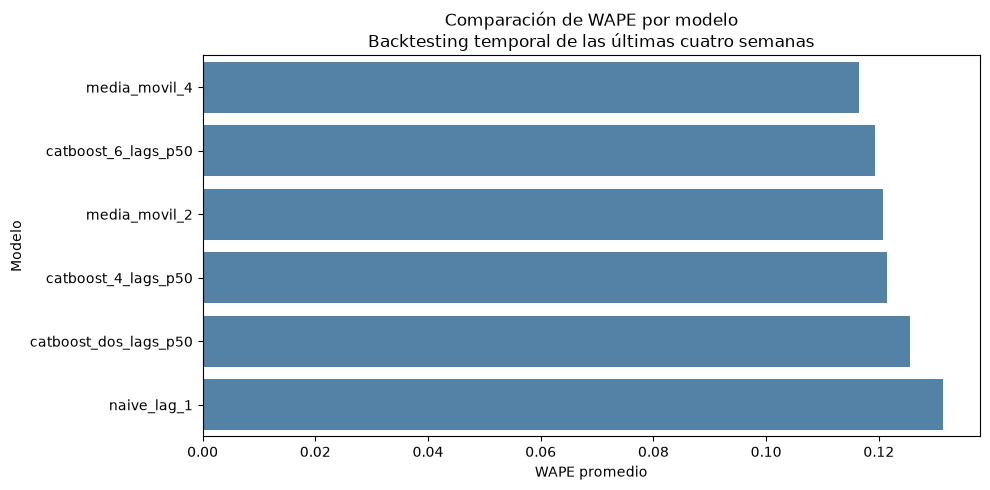

In [ ]:

# Visualización de los resultados del backtesting
resultados_grafica = comparacion_p50.copy()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resultados_grafica,
    x="wape_promedio",
    y="modelo",
    color="steelblue",
)

plt.title(
    "Comparación de WAPE por modelo\n"
    "Backtesting temporal de las últimas cuatro semanas"
)
plt.xlabel("WAPE promedio")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


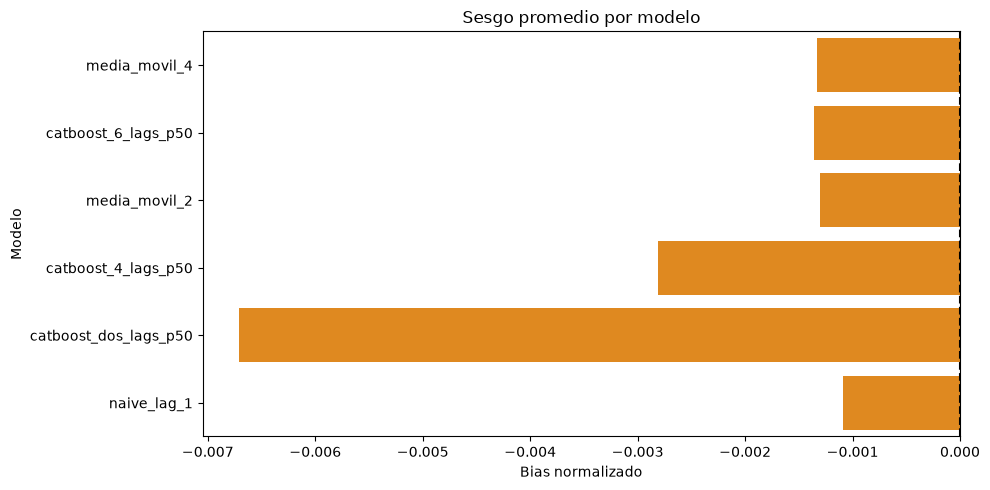

In [36]:

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resultados_grafica,
    x="bias_promedio",
    y="modelo",
    color="darkorange",
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--",
)

plt.title("Sesgo promedio por modelo")
plt.xlabel("Bias normalizado")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()



# 15. Selección del mejor modelo

In [37]:

ranking = comparacion_p50.copy()

ranking["penalizacion_bias"] = (
    ranking["bias_promedio"].abs()
)

ranking["score_experimento"] = (
    ranking["wape_promedio"]
    + 0.25 * ranking["penalizacion_bias"]
    + 0.10 * ranking["desviacion_wape"].fillna(0)
)

ranking = ranking.sort_values(
    "score_experimento"
)

ranking[
    [
        "modelo",
        "wape_promedio",
        "bias_promedio",
        "desviacion_wape",
        "score_experimento",
    ]
]


,modelo,wape_promedio,bias_promedio,desviacion_wape,score_experimento
4,media_movil_4,0.116408,-0.001329,0.006173,0.117358
1,catboost_6_lags_p50,0.119384,-0.001354,0.006645,0.120387
3,media_movil_2,0.120751,-0.001307,0.007967,0.121875
0,catboost_4_lags_p50,0.121405,-0.002806,0.004079,0.122515
2,catboost_dos_lags_p50,0.125514,-0.006712,0.007138,0.127906
5,naive_lag_1,0.131387,-0.001091,0.009272,0.132586


# 16. Guardar los resultados

In [38]:

RUTA_PROCESADOS = Path("data/processed")
RUTA_METRICAS = Path("outputs/metrics")
RUTA_PREDICCIONES = Path("outputs/predictions")

RUTA_PROCESADOS.mkdir(
    parents=True,
    exist_ok=True,
)

RUTA_METRICAS.mkdir(
    parents=True,
    exist_ok=True,
)

RUTA_PREDICCIONES.mkdir(
    parents=True,
    exist_ok=True,
)

data_modelo.to_parquet(
    RUTA_PROCESADOS / "panel_semanal.parquet",
    index=False,
)

metricas_experimentos.to_csv(
    RUTA_METRICAS / "metricas_experimentos.csv",
    index=False,
)

comparacion_p50.to_csv(
    RUTA_METRICAS / "comparacion_modelos_p50.csv",
    index=False,
)

comparacion_cuantiles.to_csv(
    RUTA_METRICAS / "comparacion_cuantiles.csv",
    index=False,
)

predicciones_experimentos.to_csv(
    RUTA_PREDICCIONES / "predicciones_backtesting.csv",
    index=False,
)


# 17. Entrenamiento final

In [41]:

def entrenar_modelos_finales(
    df: pd.DataFrame,
    lags: tuple[int, ...],
    ventanas: tuple[int, ...],
    cuantiles: tuple[float, ...],
    config: ConfiguracionExperimento,
) -> tuple[
    dict[float, CatBoostRegressor],
    list[str],
    list[str],
]:
    """Entrena un modelo final por cuantil."""

    datos = crear_variables_modelo(
        df=df,
        lags=lags,
        ventanas=ventanas,
    )

    datos = datos.dropna(
        subset=[
            "ventas_semanales",
            "ventas_lag_1",
        ]
    ).copy()

    numericas, categoricas = obtener_columnas_modelo(
        lags,
        ventanas,
    )

    X = preparar_matriz_modelo(
        datos,
        numericas,
        categoricas,
    )

    y = datos["ventas_semanales"]

    modelos = {}

    for cuantil in cuantiles:
        modelos[cuantil] = entrenar_catboost_cuantil(
            X_train=X,
            y_train=y,
            columnas_categoricas=categoricas,
            cuantil=cuantil,
            config=config,
        )

    return modelos, numericas, categoricas


In [43]:
configuracion_ganadora = CONFIGURACIONES["6_lags"]

modelos_finales, variables_numericas, variables_categoricas = (
    entrenar_modelos_finales(
        df=data_modelo,
        lags=configuracion_ganadora["lags"],
        ventanas=configuracion_ganadora["ventanas"],
        cuantiles=CONFIG.cuantiles,
        config=CONFIG,
    )
)

# 18. Predicción de la Siguiente Semana

In [44]:
def agregar_semana_futura(
    panel: pd.DataFrame,
) -> pd.DataFrame:
    """Agrega una fila futura para cada combinación SKU-Tienda."""

    panel = panel.copy()

    ultima_semana = panel["semana"].max()
    siguiente_semana = ultima_semana + pd.Timedelta(weeks=1)

    columnas_estaticas = [
        "id_tienda",
        "id_producto",
        "nombre",
        "costo_unitario",
        "precio_venta",
        "costo_almacenamiento",
        "ciudad",
        "tamano_tienda",
        "margen_unitario",
        "margen_porcentual",
    ]

    filas_futuras = (
        panel
        .sort_values("semana")
        .groupby(
            ["id_tienda", "id_producto"],
            observed=True,
            as_index=False,
        )
        .tail(1)[columnas_estaticas]
        .copy()
    )

    filas_futuras["semana"] = siguiente_semana
    filas_futuras["ventas_semanales"] = np.nan
    filas_futuras["semana_sin_registro"] = 0

    panel_futuro = pd.concat(
        [panel, filas_futuras],
        ignore_index=True,
    )

    return panel_futuro

In [45]:
panel_con_futuro = agregar_semana_futura(
    data_modelo
)

features_con_futuro = crear_variables_modelo(
    df=panel_con_futuro,
    lags=configuracion_ganadora["lags"],
    ventanas=configuracion_ganadora["ventanas"],
)

semana_pronostico = (
    features_con_futuro["semana"].max()
)

datos_pronostico = features_con_futuro[
    features_con_futuro["semana"]
    == semana_pronostico
].copy()

print("Semana pronosticada:", semana_pronostico)

Semana pronosticada: 2024-04-01 00:00:00


# 19. Pronóstico P10, P50 y P90

In [46]:
X_futuro = preparar_matriz_modelo(
    datos_pronostico,
    variables_numericas,
    variables_categoricas,
)

pronostico = datos_pronostico[
    [
        "semana",
        "id_tienda",
        "id_producto",
        "nombre",
        "precio_venta",
        "costo_unitario",
        "costo_almacenamiento",
        "margen_unitario",
    ]
].copy()

for cuantil, modelo in modelos_finales.items():
    nombre_columna = (
        f"demanda_p{int(cuantil * 100):02d}"
    )

    pronostico[nombre_columna] = np.clip(
        modelo.predict(X_futuro),
        0,
        None,
    )

In [47]:
columnas_cuantiles = [
    "demanda_p10",
    "demanda_p50",
    "demanda_p90",
]

pronostico[columnas_cuantiles] = np.sort(
    pronostico[columnas_cuantiles].to_numpy(),
    axis=1,
)

pronostico.head()

,semana,id_tienda,id_producto,nombre,precio_venta,costo_unitario,costo_almacenamiento,margen_unitario,demanda_p10,demanda_p50,demanda_p90
13,2024-04-01,STORE_01,PROD_001,Tinto,2500,800,10,1700,37.627636,45.224349,52.939534
27,2024-04-01,STORE_01,PROD_002,Café con Leche,3500,1200,15,2300,47.280926,65.179642,74.810542
41,2024-04-01,STORE_01,PROD_003,Cappuccino,4500,1500,15,3000,46.854183,60.050283,73.710672
55,2024-04-01,STORE_01,PROD_004,Pan de Bono,2800,1000,20,1800,37.667166,46.028474,54.466554
69,2024-04-01,STORE_01,PROD_005,Buñuelo,2500,800,20,1700,60.131555,72.350580,84.241446


In [48]:
pronostico.to_csv(
    "outputs/pronostico_semana_2024-04-01.csv",
    index=False,
)

# 20. Optimización

In [49]:
# Se integra el inventario actual
inventario_actual = (
    fuentes["inventario"]
    [
        [
            "id_tienda",
            "id_producto",
            "stock_actual",
        ]
    ]
    .drop_duplicates(
        subset=["id_tienda", "id_producto"]
    )
)

resultado_final = pronostico.merge(
    inventario_actual,
    on=["id_tienda", "id_producto"],
    how="left",
    validate="one_to_one",
)

resultado_final["stock_actual"] = (
    resultado_final["stock_actual"]
    .fillna(0)
    .clip(lower=0)
)

In [50]:
# Se calcula la razón crítica para cada combinación de tienda y producto
resultado_final["costo_stockout"] = (
    resultado_final["precio_venta"]
    - resultado_final["costo_unitario"]
).clip(lower=0)

resultado_final["costo_overstock"] = (
    resultado_final["costo_almacenamiento"]
    .clip(lower=0)
)

denominador = (
    resultado_final["costo_stockout"]
    + resultado_final["costo_overstock"]
)

resultado_final["razon_critica"] = np.where(
    denominador > 0,
    resultado_final["costo_stockout"] / denominador,
    0.50,
)

resultado_final["razon_critica"] = (
    resultado_final["razon_critica"]
    .clip(0.10, 0.90)
)

In [51]:
# Se interpola entre P10, P50 y P90

def interpolar_demanda_objetivo(
    fila: pd.Series,
) -> float:
    """Interpola la demanda en la razón crítica."""

    niveles = np.array(
        [0.10, 0.50, 0.90],
        dtype=float,
    )

    demandas = np.array(
        [
            fila["demanda_p10"],
            fila["demanda_p50"],
            fila["demanda_p90"],
        ],
        dtype=float,
    )

    return float(
        np.interp(
            fila["razon_critica"],
            niveles,
            demandas,
        )
    )


resultado_final["demanda_objetivo"] = (
    resultado_final.apply(
        interpolar_demanda_objetivo,
        axis=1,
    )
)

resultado_final["pedido_recomendado"] = np.ceil(
    (
        resultado_final["demanda_objetivo"]
        - resultado_final["stock_actual"]
    ).clip(lower=0)
).astype(int)

In [52]:
resultado_final.to_csv(
    "outputs/pedidos_recomendados.csv",
    index=False,
)

resultado_final.head()

,semana,id_tienda,id_producto,nombre,precio_venta,costo_unitario,costo_almacenamiento,margen_unitario,demanda_p10,demanda_p50,demanda_p90,stock_actual,costo_stockout,costo_overstock,razon_critica,demanda_objetivo,pedido_recomendado
0,2024-04-01,STORE_01,PROD_001,Tinto,2500,800,10,1700,37.627636,45.224349,52.939534,1,1700,10,0.9,52.939534,52
1,2024-04-01,STORE_01,PROD_002,Café con Leche,3500,1200,15,2300,47.280926,65.179642,74.810542,10,2300,15,0.9,74.810542,65
2,2024-04-01,STORE_01,PROD_003,Cappuccino,4500,1500,15,3000,46.854183,60.050283,73.710672,33,3000,15,0.9,73.710672,41
3,2024-04-01,STORE_01,PROD_004,Pan de Bono,2800,1000,20,1800,37.667166,46.028474,54.466554,11,1800,20,0.9,54.466554,44
4,2024-04-01,STORE_01,PROD_005,Buñuelo,2500,800,20,1700,60.131555,72.350580,84.241446,3,1700,20,0.9,84.241446,82
